In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay


from scipy.stats import randint


import warnings

warnings.filterwarnings("ignore", module="sklearn")
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("./cleaned_datasets/cleaned_kidney_disease.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      391 non-null    float64
 2   blood_pressure           388 non-null    float64
 3   specific_gravity         353 non-null    float64
 4   albumin                  354 non-null    float64
 5   sugar                    351 non-null    float64
 6   red_blood_cells          248 non-null    object 
 7   pus_cell                 335 non-null    object 
 8   pus_cell_clumps          396 non-null    object 
 9   bacteria                 396 non-null    object 
 10  blood_glucose_random     356 non-null    float64
 11  blood_urea               381 non-null    float64
 12  serum_creatinine         383 non-null    float64
 13  sodium                   313 non-null    float64
 14  potassium                3

In [4]:
# Replicate the 'plotly_dark' template globally
plt.style.use('default')

def violin(col):
    plt.figure(figsize=(10, 6), facecolor='white')
    # inner="box" draws the miniature boxplot inside, matching Plotly's box=True
    sns.violinplot(data=df, x="class", y=col, hue="class", inner="box")
    plt.title(f"Violin Plot of {col} by Class")
    plt.show()

def kde(col):
    plt.figure(figsize=(12, 6), facecolor='white')
    # fill=True and common_norm=False make the distributions easier to read
    sns.kdeplot(data=df, x=col, hue="class", fill=True, common_norm=False)
    plt.title(f"KDE Plot of {col} by Class")
    plt.show()

def scatter(col1, col2):
    plt.figure(figsize=(10, 6), facecolor='white')
    sns.scatterplot(data=df, x=col1, y=col2, hue="class")
    plt.title(f"Scatter Plot: {col1} vs {col2}")
    plt.show()

### Data Processing

In [5]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [6]:
def random_value_imputation(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(), feature] = random_sample
    
def impute_mode(feature):
    mode = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode)

In [7]:
for col in num_cols:
    random_value_imputation(col)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      400 non-null    float64
 2   blood_pressure           400 non-null    float64
 3   specific_gravity         400 non-null    float64
 4   albumin                  400 non-null    float64
 5   sugar                    400 non-null    float64
 6   red_blood_cells          248 non-null    object 
 7   pus_cell                 335 non-null    object 
 8   pus_cell_clumps          396 non-null    object 
 9   bacteria                 396 non-null    object 
 10  blood_glucose_random     400 non-null    float64
 11  blood_urea               400 non-null    float64
 12  serum_creatinine         400 non-null    float64
 13  sodium                   400 non-null    float64
 14  potassium                4

In [9]:
for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' nan] values

coronary_artery_disease has ['no' 'yes' nan] values

appetite has ['good' 'poor' nan] values

pedal_edema has ['no' 'yes' nan] values

anemia has ['no' 'yes' nan] values

classification has ['ckd' 'notckd'] values

age_group has ['41-50' '0-20' '61-70' '51-60' '21-30' '31-40' '71-80' nan '81-90'] values

class_label has ['CKD Present' 'No CKD'] values

sugar_status has ['No Sugar (su = 0)' 'Sugar Present (su > 0)'] values



In [10]:
df.drop(columns=['class_label', 'id', 'serum_creatinine', 'sugar_status', 'age_group'], axis=1)

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,138.0,3.2,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,192.0,18.0,135.0,3.9,11.3,38.0,6000.0,4.7,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,147.0,4.3,9.6,31.0,7500.0,3.2,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,147.0,5.0,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,150.0,4.9,15.7,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,141.0,3.5,16.5,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,137.0,4.4,15.8,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,135.0,4.9,14.2,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [11]:
df['classification'] = df['classification'].map({'ckd': 0, 'notckd': 1})
df['classification'] = pd.to_numeric(df['classification'], errors='coerce')

In [12]:
df.describe()

,id,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,classification
count,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,51.537500,76.40000,1.017375,1.002500,0.460000,147.375000,58.139250,3.107875,137.838750,4.686250,12.644750,38.990000,8317.250000,4.732500,0.375000
std,115.614301,17.053611,13.65673,0.005729,1.347975,1.114228,79.905548,51.185679,5.711001,9.696503,3.546835,2.900812,8.943986,2850.463171,1.033569,0.484729
min,0.000000,2.000000,50.00000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000,0.000000
25%,99.750000,42.000000,70.00000,1.010000,0.000000,0.000000,99.750000,27.000000,0.900000,135.000000,3.800000,10.475000,32.000000,6475.000000,4.000000,0.000000
50%,199.500000,54.000000,80.00000,1.020000,0.000000,0.000000,120.000000,42.000000,1.200000,138.000000,4.400000,13.000000,40.000000,8000.000000,4.800000,0.000000
75%,299.250000,64.250000,80.00000,1.020000,2.000000,0.000000,159.250000,66.250000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.425000,1.000000
max,399.000000,90.000000,180.00000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000,1.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      400 non-null    float64
 2   blood_pressure           400 non-null    float64
 3   specific_gravity         400 non-null    float64
 4   albumin                  400 non-null    float64
 5   sugar                    400 non-null    float64
 6   red_blood_cells          248 non-null    object 
 7   pus_cell                 335 non-null    object 
 8   pus_cell_clumps          396 non-null    object 
 9   bacteria                 396 non-null    object 
 10  blood_glucose_random     400 non-null    float64
 11  blood_urea               400 non-null    float64
 12  serum_creatinine         400 non-null    float64
 13  sodium                   400 non-null    float64
 14  potassium                4

In [14]:
random_value_imputation('red_blood_cells')
random_value_imputation('pus_cell')

for col in cat_cols:
    impute_mode(col)

In [15]:
df.dropna(inplace=True)

In [16]:
df.shape

(400, 29)

In [17]:
df.sample(20)

,id,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification,age_group,class_label,sugar_status
112,112,34.0,60.0,1.015,3.0,0.0,abnormal,abnormal,notpresent,notpresent,92.0,34.0,1.2,137.0,4.4,10.8,33.0,8300.0,4.7,no,no,no,good,no,no,0,51-60,CKD Present,No Sugar (su = 0)
377,377,64.0,70.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,97.0,27.0,0.7,145.0,4.8,13.8,49.0,6400.0,4.8,no,no,no,good,no,no,1,61-70,No CKD,No Sugar (su = 0)
137,137,45.0,60.0,1.010,2.0,0.0,normal,abnormal,present,notpresent,268.0,86.0,4.0,134.0,5.1,10.0,29.0,9200.0,3.4,yes,yes,no,good,no,no,0,41-50,CKD Present,No Sugar (su = 0)
5,5,60.0,90.0,1.015,3.0,0.0,normal,normal,notpresent,notpresent,74.0,25.0,1.1,142.0,3.2,12.2,39.0,7800.0,4.4,yes,yes,no,good,yes,no,0,51-60,CKD Present,No Sugar (su = 0)
103,103,76.0,70.0,1.015,2.0,0.0,normal,abnormal,present,notpresent,226.0,217.0,10.2,135.0,4.9,10.2,36.0,12700.0,4.2,yes,no,no,poor,yes,yes,0,71-80,CKD Present,No Sugar (su = 0)
241,241,57.0,70.0,1.015,1.0,0.0,normal,abnormal,notpresent,notpresent,165.0,45.0,1.5,140.0,3.3,10.4,31.0,4200.0,3.9,no,no,no,good,no,no,0,51-60,CKD Present,No Sugar (su = 0)
199,199,65.0,80.0,1.015,0.0,0.0,normal,normal,notpresent,notpresent,92.0,37.0,1.5,140.0,5.2,8.8,25.0,10700.0,3.2,yes,no,yes,good,yes,no,0,61-70,CKD Present,No Sugar (su = 0)
166,166,27.0,60.0,1.020,2.0,0.0,normal,normal,notpresent,notpresent,76.0,44.0,3.9,127.0,4.3,13.1,18.0,6900.0,4.8,no,no,no,poor,yes,yes,0,21-30,CKD Present,No Sugar (su = 0)
371,371,28.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,79.0,50.0,0.5,145.0,5.0,17.6,51.0,6500.0,5.0,no,no,no,good,no,no,1,21-30,No CKD,No Sugar (su = 0)
372,372,72.0,60.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,109.0,26.0,0.9,150.0,4.9,15.0,52.0,10500.0,5.5,no,no,no,good,no,no,1,71-80,No CKD,No Sugar (su = 0)


In [18]:
numeric_df = df.select_dtypes(include='number')

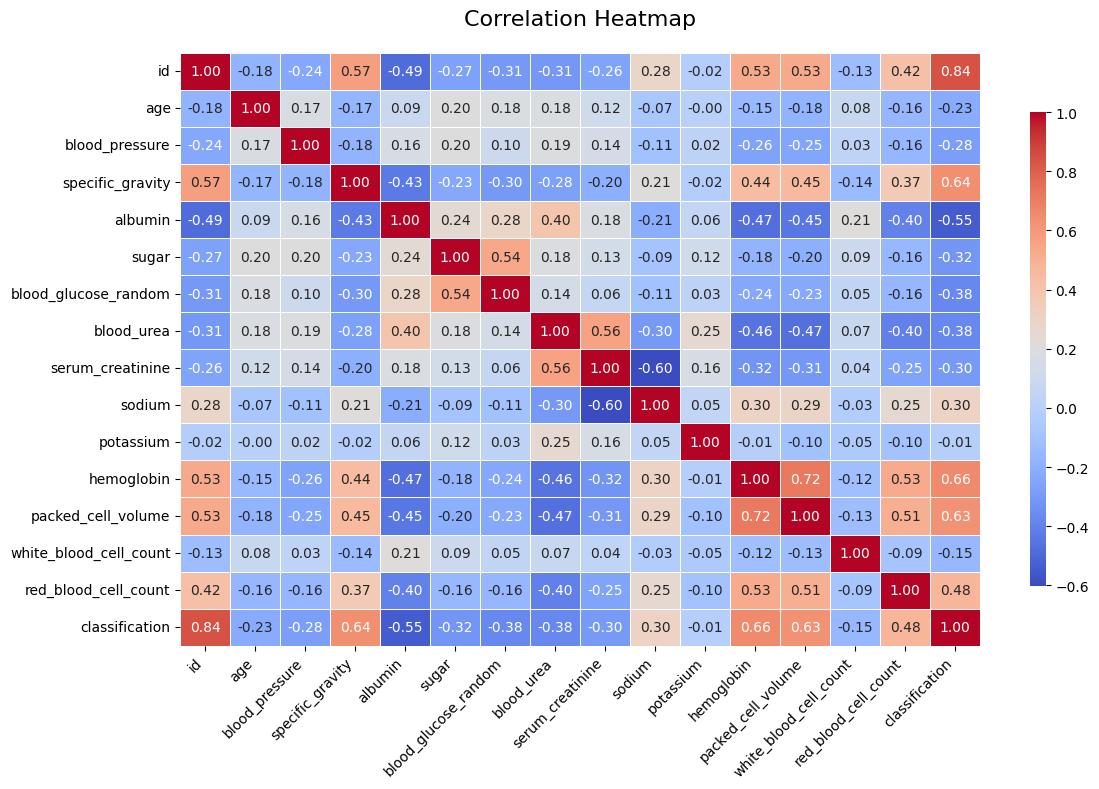

In [41]:
# Enhanced heatmap for better visualization
plt.figure(figsize=(12, 8), facecolor='white')
heatmap = sns.heatmap(
    numeric_df.corr(), 
    annot=True,  # Add correlation values
    fmt='.2f',   # Format the annotation to 2 decimal places
    cmap='coolwarm',  # Use a diverging colormap for better contrast
    linewidths=0.5,  # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'aspect': 30}  # Adjust colorbar size
)

# Customize the title and axis labels
heatmap.set_title('Correlation Heatmap', fontsize=16, pad=20)
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

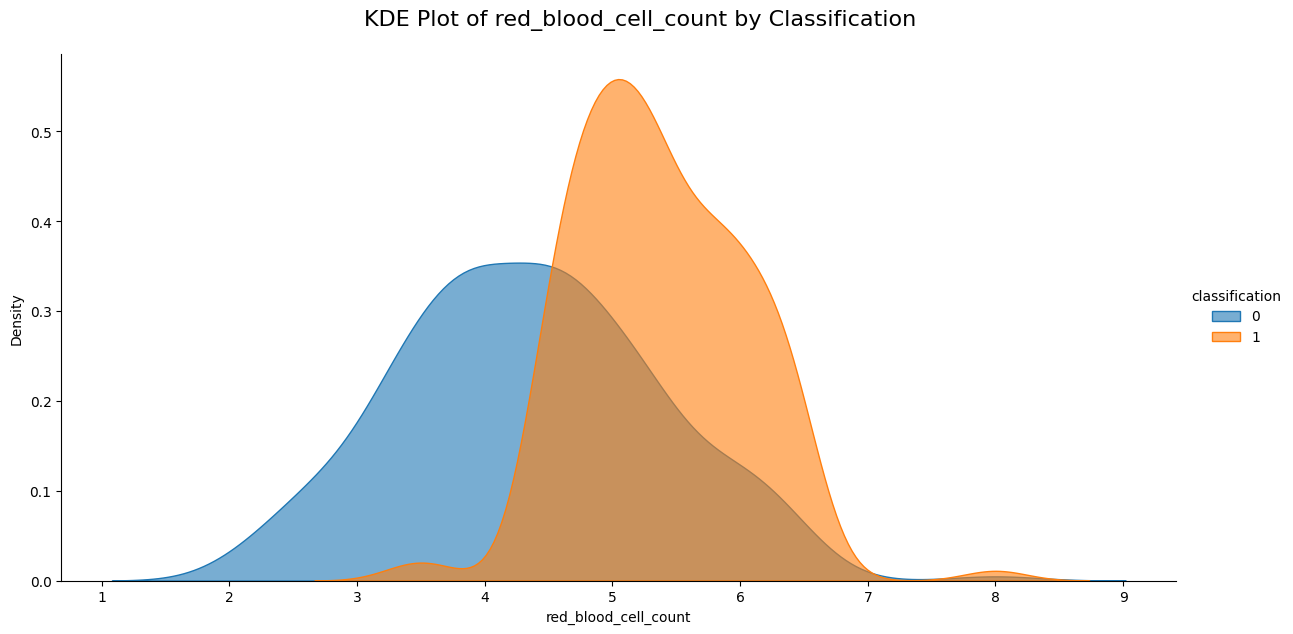

In [49]:
def kde(col):
    grid = sns.FacetGrid(df, hue="classification", height=6, aspect=2)
    grid.map(sns.kdeplot, col, fill=True, alpha=.6)  # Added fill=True for filled curves
    grid.add_legend()
    grid.figure.suptitle(f"KDE Plot of {col} by Classification", fontsize=16, y=1.05)

kde('red_blood_cell_count')

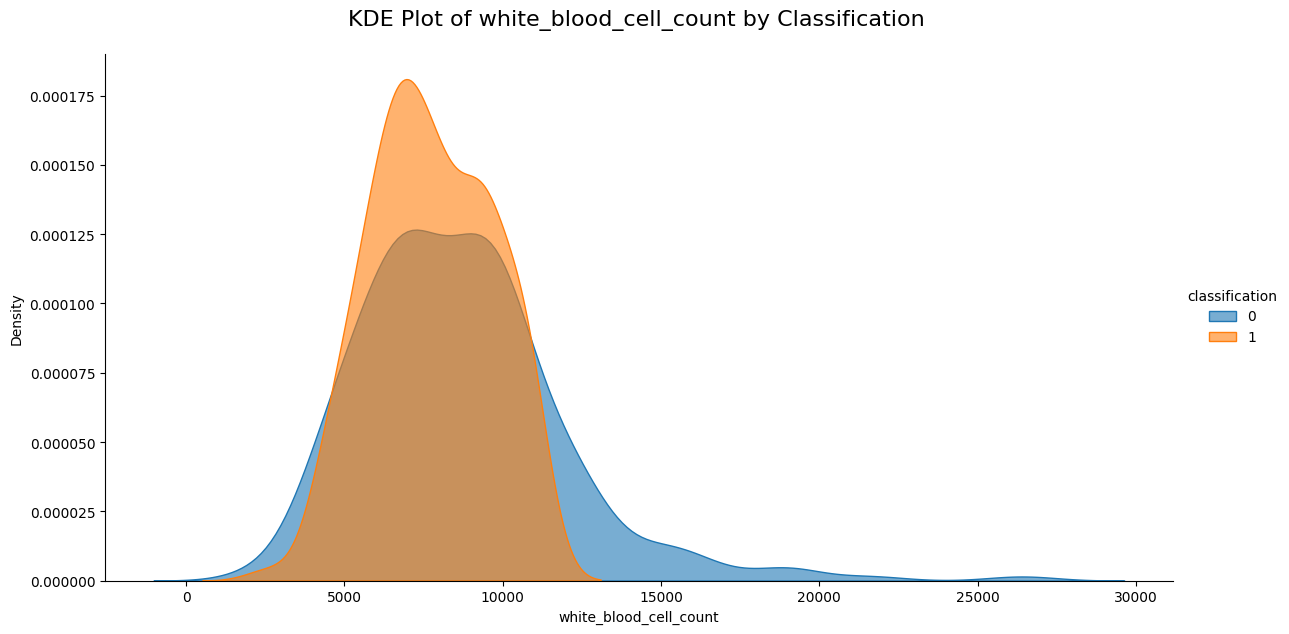

In [50]:
kde('white_blood_cell_count')


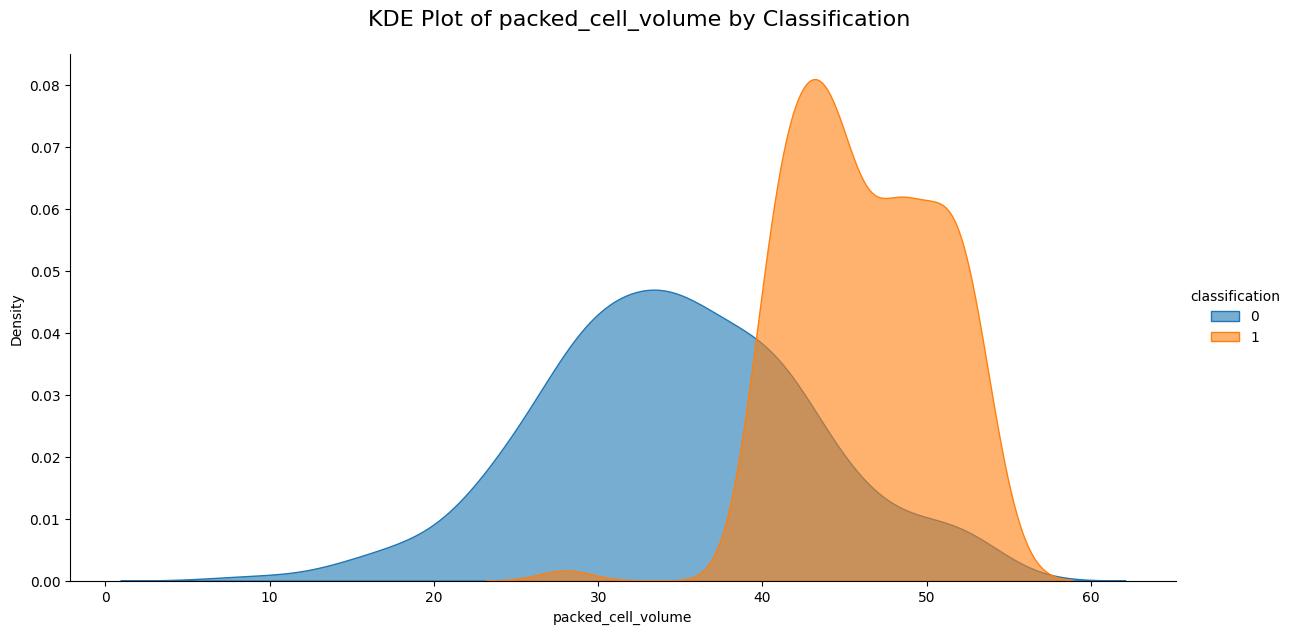

In [51]:
kde('packed_cell_volume')


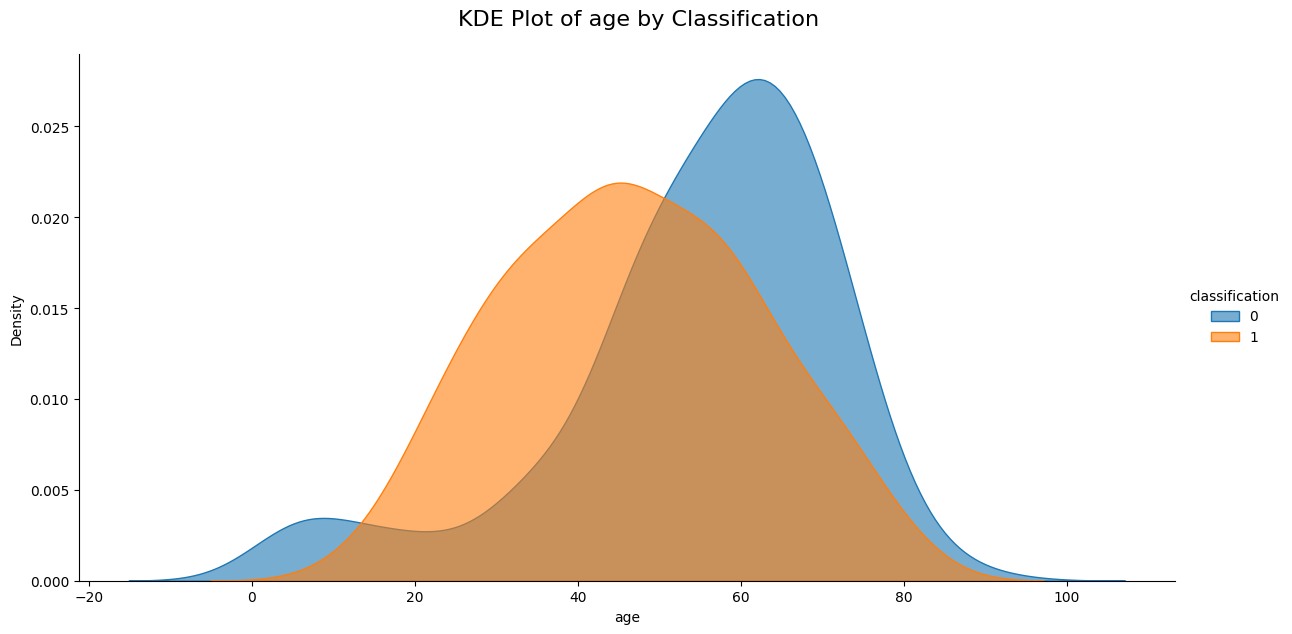

In [52]:
kde('age')

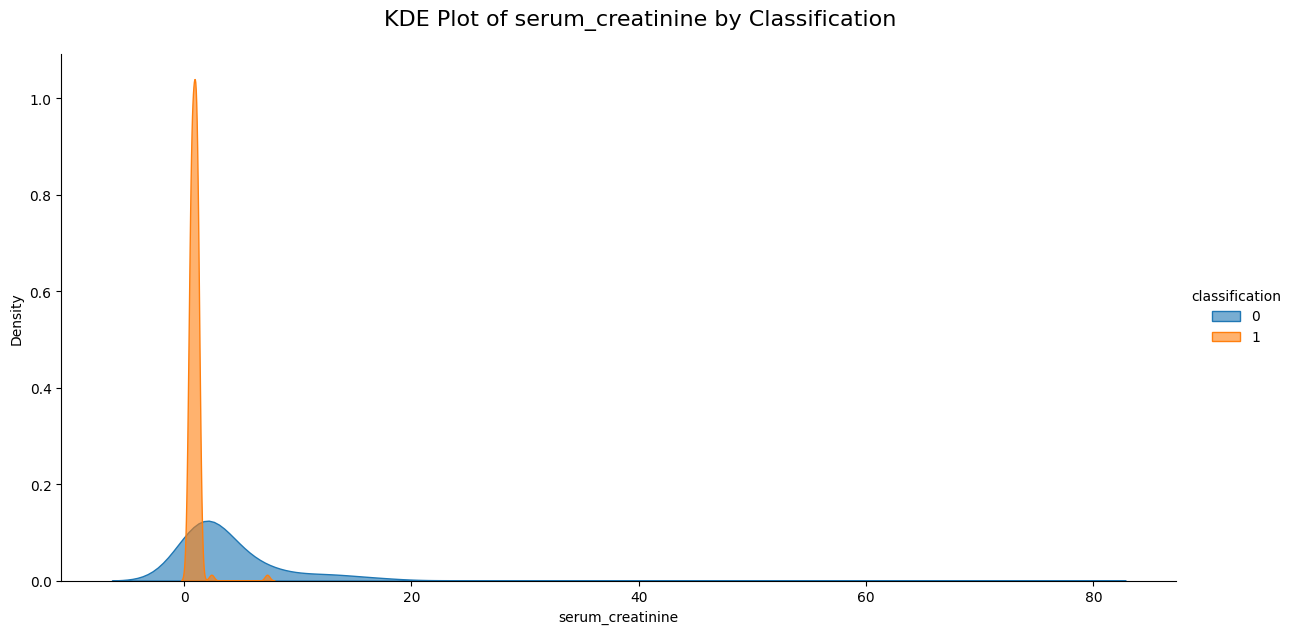

In [53]:
kde('serum_creatinine')

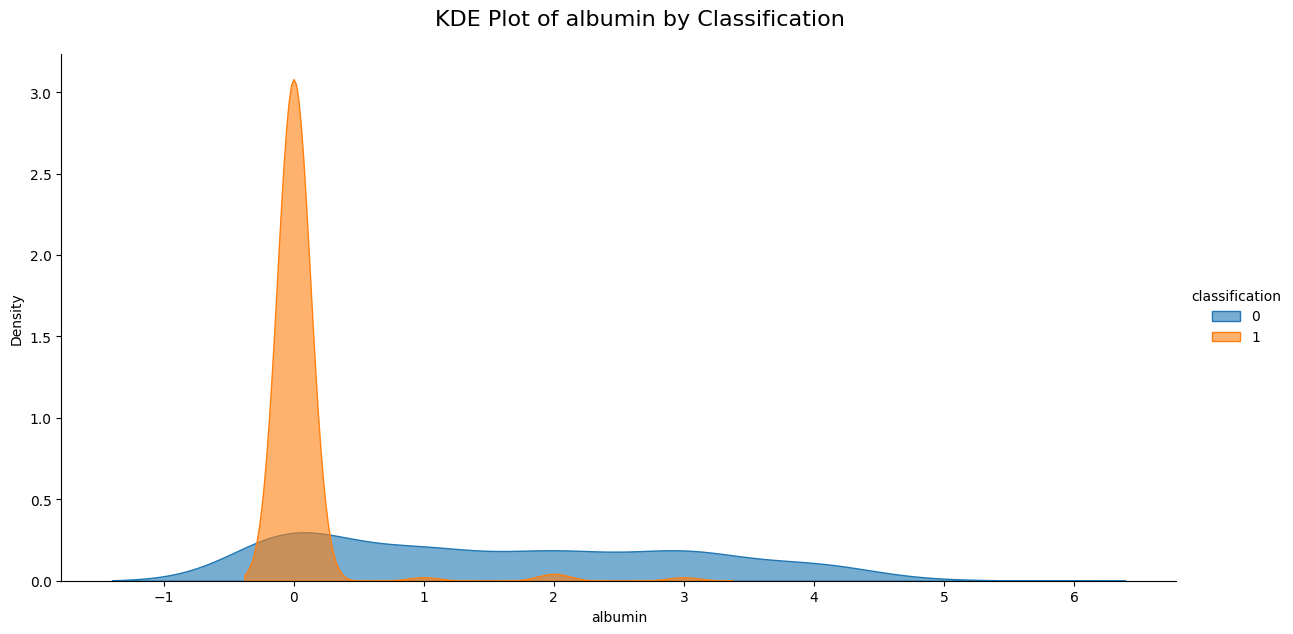

In [54]:
kde('albumin')

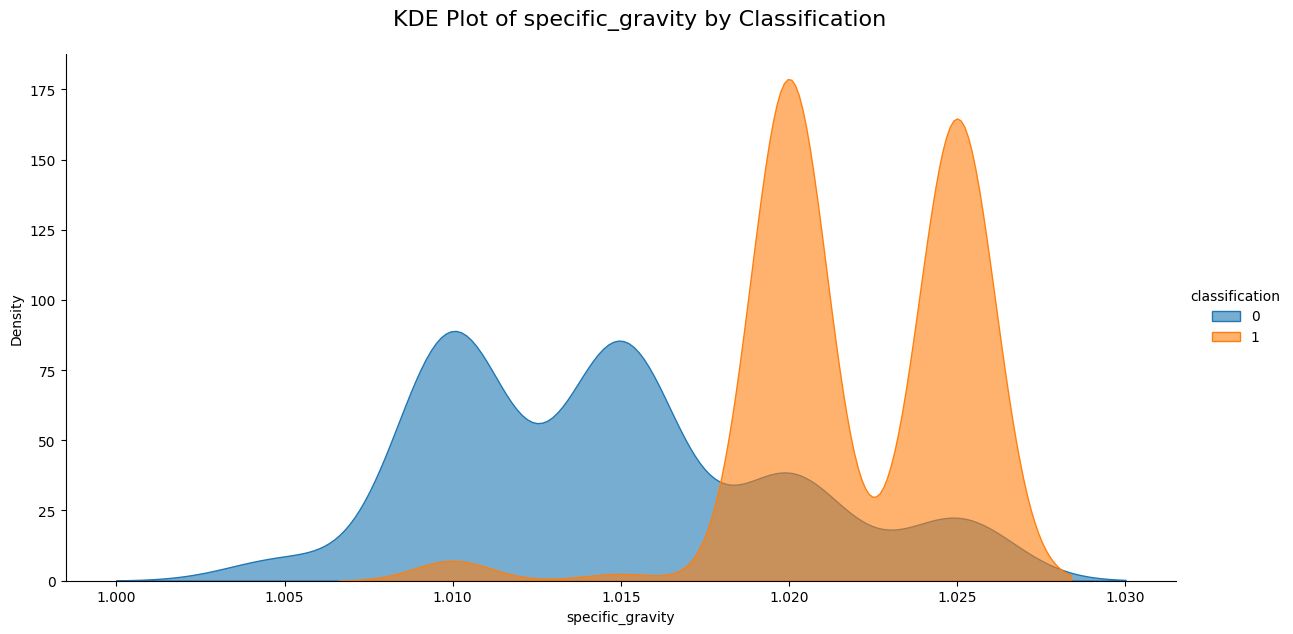

In [55]:
kde('specific_gravity')

### Random Forest

In [26]:
X = df.drop(columns=['classification', 'class_label', 'id', 'serum_creatinine', 'albumin', 'specific_gravity'], axis=1)
y = df[['class_label']]

In [27]:
random_seed = 42

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.2, random_state = random_seed)

In [28]:
# One-hot encode categorical features (AFTER train-test split to avoid leakage)
# Identify categorical columns in X_train
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}\n")

# One-hot encode train and test data
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure test has same columns as train (in case some categories only appear in one set)
# Add missing columns to test with 0s
for col in X_train_encoded.columns:
    if col not in X_test_encoded.columns:
        X_test_encoded[col] = 0

# Remove extra columns from test that aren't in train
X_test_encoded = X_test_encoded[X_train_encoded.columns]

print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}\n")

# Encode target variable
y_train_encoded = y_train['class_label'].map({'No CKD': 0, 'CKD Present': 1})
y_test_encoded = y_test['class_label'].map({'No CKD': 0, 'CKD Present': 1})

print(f"y_train_encoded shape: {y_train_encoded.shape}")
print(f"y_test_encoded shape: {y_test_encoded.shape}")
print(f"\nEncoding complete! Ready for model training.")

Categorical columns to encode: ['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia', 'age_group', 'sugar_status']

X_train_encoded shape: (320, 29)
X_test_encoded shape: (80, 29)

y_train_encoded shape: (320,)
y_test_encoded shape: (80,)

Encoding complete! Ready for model training.


In [29]:
# Implement Random Forest model
rfc = RandomForestClassifier(random_state=random_seed, n_jobs=-2)
rfc.fit(X_train_encoded, y_train_encoded)

RandomForestClassifier(n_jobs=-2, random_state=42)

In [30]:
skfold = StratifiedKFold(n_splits=5, random_state=random_seed, shuffle=True)


# Tune Hyperparameters using RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(50, 250, 20),  # Adjusted for larger datasets
    'max_depth': [None, 2, 5, 10, 20, 30],  # Added deeper trees for complex data
    'min_samples_split': randint(3, 12, 3),  # Standard values for splitting
    'min_samples_leaf': [1, 2, 4],  # Added leaf size for regularization
    'max_leaf_nodes': [None, 10, 20, 50, 100],  # More options for leaf nodes
    'criterion': ['gini']  # Evaluate both splitting criteria
}
random_search = RandomizedSearchCV(estimator=rfc, param_distributions=param_distributions, cv=skfold, n_iter=30, random_state=random_seed, n_jobs=-1)
random_search.fit(X_train_encoded, y_train_encoded)

print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Score:", random_search.best_score_)

results_df = pd.DataFrame(random_search.cv_results_)

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'max_leaf_nodes': 50, 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 244}
Best Cross-Validation Score: 0.978125


In [31]:
# Sort the models by their mean test score (Precision) in descending order
top_10_models = results_df.sort_values(by='mean_test_score', ascending=False).head(20)

# Select only the most relevant columns so the output isn't overwhelmingly wide
columns_to_show = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']

print("Top 10 Hyperparameter Combinations:")
# Setting max_colwidth allows the dictionary of parameters to print fully
with pd.option_context('display.max_colwidth', None): 
    print(top_10_models[columns_to_show])

Top 10 Hyperparameter Combinations:
    rank_test_score  mean_test_score  std_test_score  \
15                1         0.978125        0.023385   
14                1         0.978125        0.023385   
10                1         0.978125        0.023385   
21                4         0.975000        0.025388   
4                 4         0.975000        0.021195   
27                4         0.975000        0.023385   
25                4         0.975000        0.025388   
24                4         0.975000        0.025388   
18                4         0.975000        0.023385   
16               10         0.971875        0.025000   
19               10         0.971875        0.025000   
17               10         0.971875        0.020729   
11               10         0.971875        0.028641   
26               10         0.971875        0.028641   
28               10         0.971875        0.025000   
2                10         0.971875        0.028641   
20          

In [32]:
# 1. Initialize the model with your new optimal parameters
optimized_rf = RandomForestClassifier(
    n_estimators=78,         # Updated from 170
    max_depth=None,          # Updated from 2 (allows trees to grow until max_leaf_nodes is hit)
    max_leaf_nodes=50,       # Kept at 50
    min_samples_split=7,     # Updated from 10
    min_samples_leaf=2,      # Kept at 2
    criterion='gini',        # Kept as 'gini'
    class_weight='balanced_subsample', 
    random_state=42          # Match the random_seed you used previously
)

# 2. Fit the model to the training data
optimized_rf.fit(X_train_encoded, y_train_encoded)

# 3. Generate predictions and probabilities for the test set
y_pred = optimized_rf.predict(X_test_encoded)
y_pred_proba = optimized_rf.predict_proba(X_test_encoded)[:, 1] # Get probabilities for the positive class

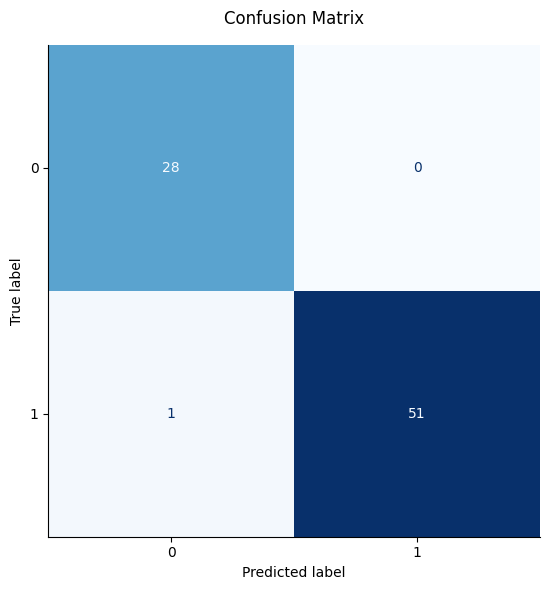

In [33]:
# Plot 1: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, 
    y_pred, 
    ax=ax, 
    cmap='Blues', 
    colorbar=False
)
ax.set_title('Confusion Matrix', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

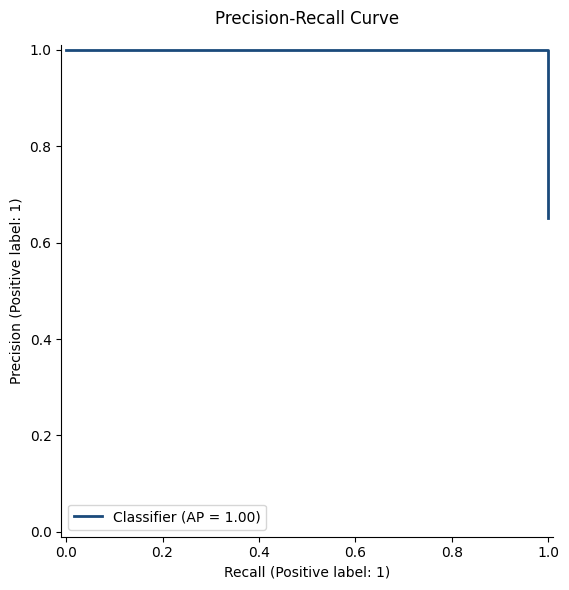

In [34]:
# Plot 2: Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
PrecisionRecallDisplay.from_predictions(
    y_test_encoded, 
    y_pred_proba, 
    ax=ax, 
    color='#1A4A7B',
    linewidth=2
)
ax.set_title('Precision-Recall Curve', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [35]:
# Print Text Metrics
print("Test Set Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred))

Test Set Accuracy: 0.9875

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       1.00      0.98      0.99        52

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



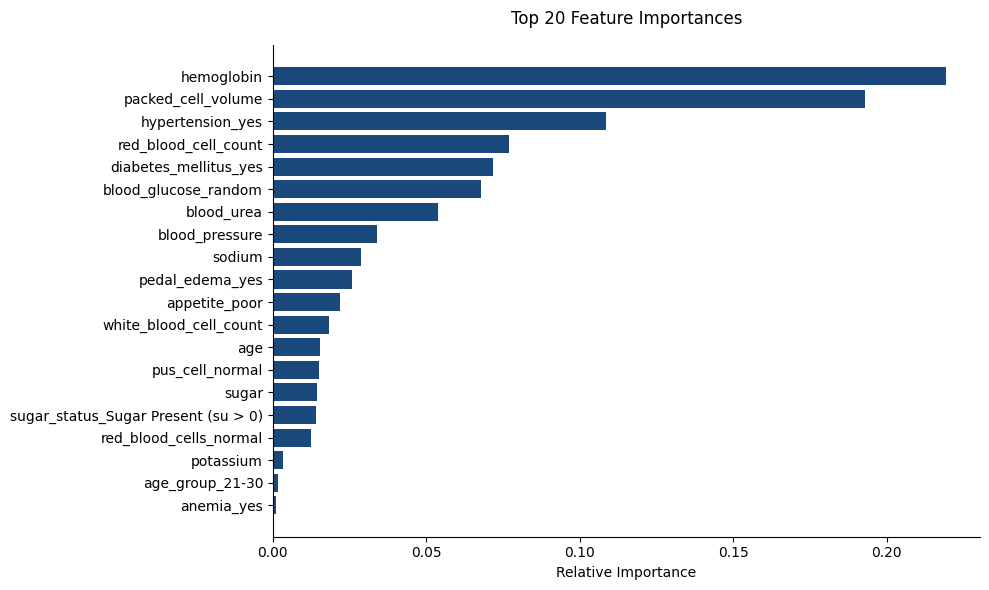

In [43]:
# Plot 3: Top 10 Feature Importances
importances = optimized_rf.feature_importances_

# Safely extract column names if X_train is a DataFrame
if hasattr(X_train_encoded, 'columns'):
    feature_names = X_train_encoded.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_train_encoded.shape[1])]

# Get indices of the top 20 most important features
top_20_indices = np.argsort(importances)[::-1][:20]
top_20_importances = importances[top_20_indices]
top_20_names = [feature_names[i] for i in top_20_indices]

# Create a horizontal bar chart (reversing order so the highest is at the top)
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.barh(range(20), top_20_importances[::-1], align='center', color='#1A4A7B')
ax.set_yticks(range(20))
ax.set_yticklabels(top_20_names[::-1])
ax.set_title('Top 20 Feature Importances', pad=15)
ax.set_xlabel('Relative Importance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

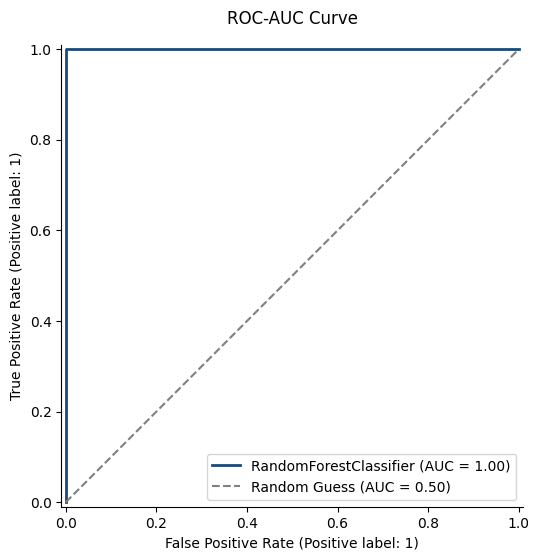

In [37]:
from sklearn.metrics import RocCurveDisplay

# Plot the ROC curve (The simplest way)
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    optimized_rf, 
    X_test_encoded, 
    y_test_encoded, 
    ax=ax, 
    color='#1A4A7B',
    linewidth=2
)

# Add the 50/50 random guess line for context
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.50)')

plt.title('ROC-AUC Curve', pad=15)
plt.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

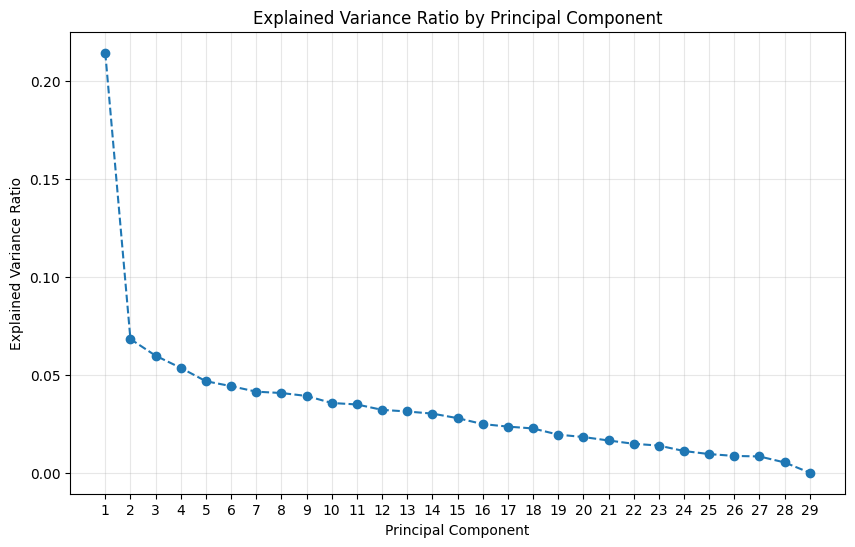

In [45]:
# Import necessary libraries for PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale the X variable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_encoded)  # Use the training data for scaling to avoid data leakage

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Visualize explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Principal Component')
plt.xlabel('Principal Component')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.ylabel('Explained Variance Ratio')
plt.grid(alpha=0.3)
plt.show()


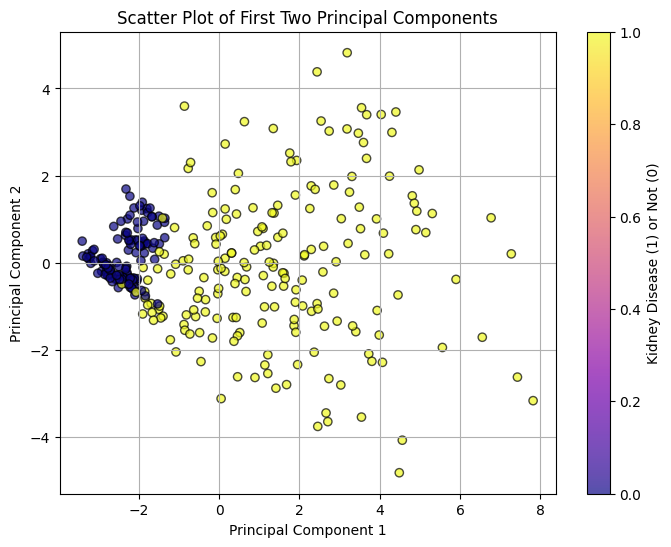

In [48]:
# Scatter plot of the first two principal components with color for cancerous cases
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_encoded, cmap='plasma', alpha=0.7, edgecolor='k')
plt.title('Scatter Plot of First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Kidney Disease (1) or Not (0)')
plt.grid(True)
plt.show()